## Machine Learning Supervised

## Table of Contents

So far, we have focused on using KNN as our model to predict California housing prices. However, there are other models worth exploring. Today, we will experiment with both simple Linear Regression and Decision Trees to understand how they explain our target variable. In machine learning, we typically choose our model based on the relationship between our features and the target variable, or simply by selecting the model with the higher score

Yesterday, we applied some feature engineering techniques, and our model indeed increased its performance. Now, let's see how Linear Regression and Decision Tree perform when we apply the same feature engineering techniques.

#### Loading and preparing the data

In [1]:
from sklearn.datasets import  fetch_california_housing
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [2]:
california = fetch_california_housing()
print(california["DESCR"])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
df_cali = pd.DataFrame(california["data"], columns = california["feature_names"])
df_cali["median_house_value"] = california["target"]

df_cali.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Normalization & Feature Selection

Like we did in Feature Engineering lesson, we are going to normalize our data and select a subset of columns as our features.

#### Train Test Split

In [4]:
features = df_cali.drop(columns = ["median_house_value","AveOccup", "Population", "AveBedrms"])
target = df_cali["median_house_value"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=0)

Create an instance of the normalizer

In [6]:
normalizer = MinMaxScaler() # x_new = (x - min(x)) / (max(x) -min(x))

normalizer.fit(X_train)

MinMaxScaler()

In [7]:
scaler = StandardScaler() # x_new = (x - mean(x)) / std(x)

scaler.fit(X_train)

StandardScaler()

In [8]:
X_train_norm_np = normalizer.transform(X_train)
X_test_norm_np = normalizer.transform(X_test)

In [9]:
X_train_norm_df = pd.DataFrame(X_train_norm_np, columns = X_train.columns, index=X_train.index)
X_train_norm_df.head()

,MedInc,HouseAge,AveRooms,Latitude,Longitude
12069,0.257838,0.098039,0.048751,0.137088,0.677291
15925,0.268265,1.000000,0.031762,0.551541,0.190239
11162,0.236783,0.490196,0.027097,0.137088,0.632470
4904,0.066578,0.725490,0.017987,0.156217,0.606574
4683,0.184591,1.000000,0.023207,0.163656,0.596614


In [10]:
X_test_norm_df = pd.DataFrame(X_test_norm_np, columns = X_test.columns, index=X_test.index)
X_test_norm_df.head()

,MedInc,HouseAge,AveRooms,Latitude,Longitude
14740,0.251852,0.411765,0.034147,0.004251,0.727092
10101,0.364112,0.607843,0.037296,0.146652,0.635458
20566,0.265431,0.549020,0.036045,0.649309,0.250000
2670,0.134564,0.705882,0.029397,0.070138,0.871514
15709,0.310685,0.470588,0.024621,0.557917,0.191235


In [11]:
X_train_standarized_np = scaler.transform(X_train)
X_test_standarized_np = scaler.transform(X_test)

X_train_standarized_df = pd.DataFrame(X_train_standarized_np, columns = X_train.columns, index=X_train.index)
X_test_standarized_df  = pd.DataFrame(X_test_standarized_np, columns = X_test.columns, index=X_test.index)


In [12]:
X_train_norm_df.describe()

,MedInc,HouseAge,AveRooms,Latitude,Longitude
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,0.232852,0.541550,0.032514,0.327820,0.476792
std,0.131500,0.247078,0.017889,0.227051,0.199726
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142531,0.333333,0.025531,0.147715,0.253984
50%,0.210245,0.549020,0.031107,0.181722,0.583665
75%,0.292939,0.705882,0.036954,0.549416,0.632470
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
X_train_standarized_df.describe()

,MedInc,HouseAge,AveRooms,Latitude,Longitude
count,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04
mean,-9.778999e-17,-7.939386e-17,-3.262356e-17,6.915226e-16,-1.134805e-14
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00
min,-1.770783e+00,-2.191882e+00,-1.817613e+00,-1.443857e+00,-2.387300e+00
25%,-6.868704e-01,-8.427417e-01,-3.903412e-01,-7.932566e-01,-1.115601e+00
50%,-1.719169e-01,3.023146e-02,-7.861158e-02,-6.434780e-01,5.351153e-01
75%,4.569491e-01,6.651210e-01,2.482430e-01,9.760028e-01,7.794811e-01
max,5.833981e+00,1.855539e+00,5.408569e+01,2.960569e+00,2.619705e+00


## Linear Regression

Let's create an instance of Linear Regression model.

In [14]:
lin_reg = LinearRegression()

In [15]:
lin_reg2 = LinearRegression()

Training Linear Regression with our normalized data

In [16]:
lin_reg.fit(X_train_norm_df, y_train) # Determines the b0 and b1's values

LinearRegression()

In [17]:
lin_reg2.fit(X_train_standarized_df, y_train)

LinearRegression()

In [18]:
import pickle

with open("linear_model_normalized.pkl", "wb") as file:
    pickle.dump(lin_reg, file)

with open("min_max_scaler.pkl", "wb") as file:
    pickle.dump(normalizer, file)

Evaluate model's performance

In [19]:
y_pred_test = lin_reg.predict(X_test_norm_df)

print(f"MAE {mean_absolute_error(y_pred_test, y_test): .2f}") # mean(abs(error)) = mean(abs(y_test - y_pred_test))
print(f"MSE {mean_squared_error(y_pred_test, y_test): .2f}") # mean(error**2) = mean((y_test - y_pred_test)**2)
print(f"RMSE, {root_mean_squared_error(y_pred_test, y_test): .2f}") # sqrt( mean( (y_test - y_pred_test)**2 ) ) # b0, b1, b2...
print(f"R2 score, {lin_reg.score(X_test_norm_df, y_test): .2f}") # r2_score

MAE  0.55
MSE  0.55
RMSE,  0.74
R2 score,  0.58


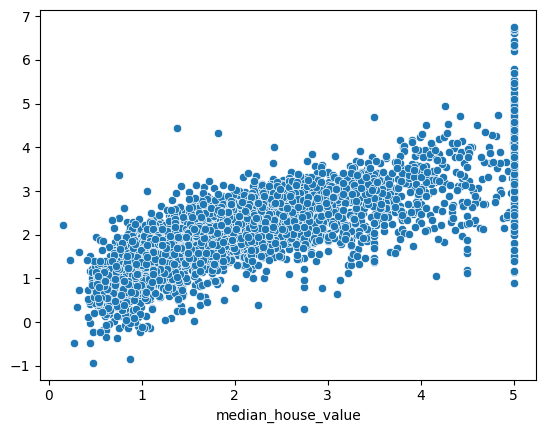

In [20]:
sns.scatterplot(x=y_test, y=y_pred_test); # y_pred_test = y_test;  y_pred_test = 0 + y_test; y_pred_test = 0 + 1 * y_test

In [21]:
y_pred_test2 = lin_reg2.predict(X_test_standarized_df)

#lin_reg.score(X_test_norm_df, y_test)

print(f"MAE {mean_absolute_error(y_pred_test2, y_test): .2f}") # mean(abs(error)) = mean(abs(y_test - y_pred_test))
print(f"MSE {mean_squared_error(y_pred_test2, y_test): .2f}")
print(f"RMSE, {root_mean_squared_error(y_pred_test2, y_test): .2f}") # sqrt( mean( (y_test - y_pred_test)^2 ) ) # b0, b1, b2...
print(f"R2 score, {lin_reg2.score(X_test_standarized_df, y_test): .2f}")

MAE  0.55
MSE  0.55
RMSE,  0.74
R2 score,  0.58


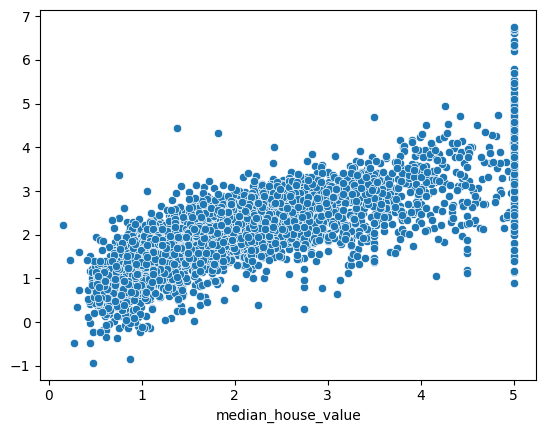

In [22]:
sns.scatterplot(x=y_test, y=y_pred_test2);

In [23]:
results = pd.DataFrame({"y_test": y_test, "lin_reg": y_pred_test, "lin_reg2": y_pred_test2})
results

,y_test,lin_reg,lin_reg2
14740,1.369,2.337576,2.337576
10101,2.413,2.862364,2.862364
20566,2.007,1.936865,1.936865
2670,0.725,0.883635,0.883635
15709,4.600,2.779784,2.779784
...,...,...,...
6655,1.695,1.572949,1.572949
3505,2.046,2.440601,2.440601
1919,1.286,0.802477,0.802477
1450,2.595,2.887172,2.887172


In [24]:
results_melted = results.melt(id_vars="y_test")
results_melted

,y_test,variable,value
0,1.369,lin_reg,2.337576
1,2.413,lin_reg,2.862364
2,2.007,lin_reg,1.936865
3,0.725,lin_reg,0.883635
4,4.600,lin_reg,2.779784
...,...,...,...
8251,1.695,lin_reg2,1.572949
8252,2.046,lin_reg2,2.440601
8253,1.286,lin_reg2,0.802477
8254,2.595,lin_reg2,2.887172


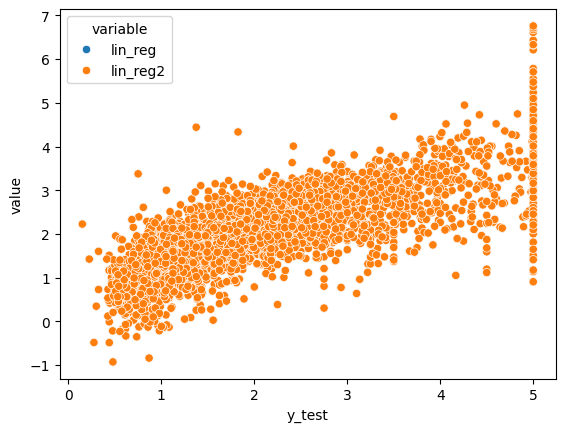

In [25]:
sns.scatterplot(data=results_melted, y="value", x="y_test", hue="variable");

Linear Regression yielding a worse score than our previous model, KNN.

In Linear Regression, we often assess feature importance by examining the coefficients in the model. These coefficients indicate the impact of each feature on the model's predictions. However, in order to do this kind of analysis **all the column's values should be transformed to a common scale before training the model!!**

- Determine the coefficients (β) in the linear regression equation corresponding to each feature.
- The magnitude of these coefficients reflects the relative importance of the features. **Greater absolute values suggest more substantial impacts.**

In [26]:
lin_reg_coef = {feature : coef for feature, coef in zip(X_train_norm_df.columns, lin_reg.coef_)}
lin_reg_coef

{'MedInc': np.float64(5.384646061206897),
 'HouseAge': np.float64(0.49426222880241255),
 'AveRooms': np.float64(2.477107236982316),
 'Latitude': np.float64(-4.293927324319665),
 'Longitude': np.float64(-4.660457306574648)}

In [27]:
lin_reg.intercept_

np.float64(4.100169305445689)

$$y_pred = 4.10 + 5.38 * MedInc_{norm} + 0.49 * HouseAge_{norm} + 2.48 * AveRooms_{norm} - 4.29 * Latitude_{norm} - 4.66 * Longitude_{norm} $$

We can conclude that **Median Income** have the highest and positive impact in our model.

## Decision Tree

So far between KNN and Linear Regression, the first yield a better score, let's see how a Decision Tree performs.

- Initialize a Decision Tree instance

- Setting max_depth as 10, this means we will allow our tree to split 10 times

In [28]:
tree = DecisionTreeRegressor(max_depth=10)

- Training the model

Note: Decision Trees are not "distance" based models. Therefore, we don't need to have the data before training them. If we do so, the model with adapt to the new transformed data and the changes in the predictions will be small.

Here, for simplicity we will train a Decision Tree with transformed data

In [29]:
tree.fit(X_train_norm_df, y_train)

DecisionTreeRegressor(max_depth=10)

- Evaluate the model

In [30]:
X_train_norm_df

,MedInc,HouseAge,AveRooms,Latitude,Longitude
12069,0.257838,0.098039,0.048751,0.137088,0.677291
15925,0.268265,1.000000,0.031762,0.551541,0.190239
11162,0.236783,0.490196,0.027097,0.137088,0.632470
4904,0.066578,0.725490,0.017987,0.156217,0.606574
4683,0.184591,1.000000,0.023207,0.163656,0.596614
...,...,...,...,...,...
13123,0.269831,0.372549,0.036536,0.608927,0.307769
19648,0.166453,0.509804,0.031923,0.524973,0.344622
9845,0.186053,0.588235,0.019814,0.429330,0.244024
10799,0.353899,0.647059,0.026190,0.114772,0.639442


In [31]:
y_test

,median_house_value
14740,1.369
10101,2.413
20566,2.007
2670,0.725
15709,4.600
...,...
6655,1.695
3505,2.046
1919,1.286
1450,2.595


In [32]:
y_pred_test_dt = tree.predict(X_test_norm_df)

print(f"MAE, {mean_absolute_error(y_pred_test_dt, y_test): .2f}")
print(f"MSE, {mean_squared_error(y_pred_test_dt, y_test): .2f}")
print(f"RMSE, {root_mean_squared_error(y_pred_test_dt, y_test): .2f}")
print(f"R2 score, {tree.score(X_test_norm_df, y_test): .2f}")

MAE,  0.42
MSE,  0.40
RMSE,  0.63
R2 score,  0.70


Often we check what are the most relevant features, like we did before in Linear Regression. However, here we don't have coefficients. Therefore, to do this kind of analisys, we check in which order were the features selected to split the data. The intuition behind this method is that the most important features will be selected first, while less important fetures will be used in later splits.

Fortunatelly for us, this information in stored in the instance of the class and it can be accessed trough the attribute `.feature_importances_` once the model has been trained.

In [33]:
tree_importance = {feature : importance for feature, importance in zip(X_train_norm_df.columns, tree.feature_importances_)}
tree_importance

{'MedInc': np.float64(0.6218902350774984),
 'HouseAge': np.float64(0.05851162253212554),
 'AveRooms': np.float64(0.04577563024789357),
 'Latitude': np.float64(0.14111118767154684),
 'Longitude': np.float64(0.1327113244709357)}

In [34]:
from sklearn.tree import export_text

tree_viz = export_text(tree, feature_names=list(X_train_norm_df.columns))
print(tree_viz)


|--- MedInc <= 0.31
|   |--- MedInc <= 0.18
|   |   |--- AveRooms <= 0.02
|   |   |   |--- MedInc <= 0.12
|   |   |   |   |--- AveRooms <= 0.02
|   |   |   |   |   |--- Latitude <= 0.16
|   |   |   |   |   |   |--- Longitude <= 0.59
|   |   |   |   |   |   |   |--- value: [4.50]
|   |   |   |   |   |   |--- Longitude >  0.59
|   |   |   |   |   |   |   |--- Longitude <= 0.72
|   |   |   |   |   |   |   |   |--- HouseAge <= 0.23
|   |   |   |   |   |   |   |   |   |--- HouseAge <= 0.15
|   |   |   |   |   |   |   |   |   |   |--- value: [3.25]
|   |   |   |   |   |   |   |   |   |--- HouseAge >  0.15
|   |   |   |   |   |   |   |   |   |   |--- value: [3.50]
|   |   |   |   |   |   |   |   |--- HouseAge >  0.23
|   |   |   |   |   |   |   |   |   |--- Latitude <= 0.13
|   |   |   |   |   |   |   |   |   |   |--- value: [1.94]
|   |   |   |   |   |   |   |   |   |--- Latitude >  0.13
|   |   |   |   |   |   |   |   |   |   |--- value: [1.49]
|   |   |   |   |   |   |   |--- Longitude >  

A bit overwhelming to see, let's use graphviz library.

**Note**: you will need to install graphivz

* pip install graphviz
* conda install graphviz -y

depending on your environment and package mannager.

In [35]:
#!pip install graphviz

- We will train a decision tree, in this case with max_depth=2 to better see the diagram

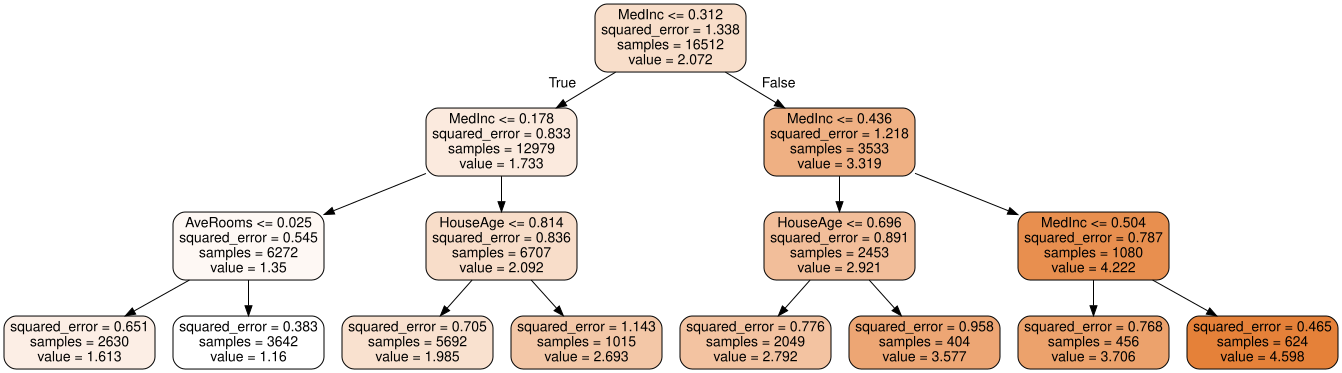

In [37]:
from sklearn.tree import DecisionTreeRegressor, export_graphviz
import graphviz

tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X_train_norm_df, y_train)


dot_data = export_graphviz(tree, out_file="tree.dot", filled=True, rounded=True, feature_names=X_train_norm_df.columns)

with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

In [ ]:
graphviz.__version__

'0.21'